# PR Throughput Analysis

**Section 3 of Baseline System Productivity Report**

> A high-level proxy for engineering output volume.

## What we're measuring

1. **PR throughput**: Merged PRs over time — raw and normalized per contributor
2. **Breakdown by Area**: PR throughput across top-level Swarmia teams
3. **Work granularity**: Commits per PR — how development patterns are shifting

## Data caveats

- Area breakdown uses Swarmia's `owner_team_names` filtered to top-level teams, excluding AI Pilot, Productivity, Quant, and Test Team. Historically accurate but team names have evolved.

In [1]:
import snowflake.connector
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# Render as both interactive plotly + static PNG fallback
pio.renderers.default = 'plotly_mimetype+png'
pio.defaults.default_width = 900
pio.defaults.default_height = 500
pio.defaults.default_scale = 2

# Connect using SSO (will open browser, or use cached token)
conn = snowflake.connector.connect(
    account='wt74883-sb_prod',
    user='jeroen.vaelen@happening.xyz',
    authenticator='externalbrowser'
)

def run_query(sql):
    """Run SQL and return pandas DataFrame"""
    cur = conn.cursor()
    cur.execute(sql)
    df = cur.fetch_pandas_all()
    df.columns = df.columns.str.lower()
    return df

print('Connected!')

Connected!


## 1. Data Exploration

First, let's understand what data we have.

In [2]:
# What's the date range and volume?
df_overview = run_query("""
SELECT 
  MIN(github_created_at)::DATE as earliest_pr,
  MAX(github_created_at)::DATE as latest_pr,
  COUNT(*) as total_prs,
  COUNT(CASE WHEN pr_status = 'MERGED' THEN 1 END) as merged_prs,
  COUNT(CASE WHEN pr_status = 'OPEN' THEN 1 END) as open_prs,
  COUNT(CASE WHEN pr_status = 'CLOSED' THEN 1 END) as closed_prs,
  COUNT(DISTINCT author_id) as unique_authors
FROM RAW_MISC.SWARMIA_PULL_REQUESTS
""")

print("=" * 50)
print("DATA OVERVIEW")
print("=" * 50)
print(f"Date range: {df_overview['earliest_pr'].iloc[0]} to {df_overview['latest_pr'].iloc[0]}")
print(f"Total PRs: {df_overview['total_prs'].iloc[0]:,}")
print(f"  - Merged: {df_overview['merged_prs'].iloc[0]:,}")
print(f"  - Open: {df_overview['open_prs'].iloc[0]:,}")
print(f"  - Closed: {df_overview['closed_prs'].iloc[0]:,}")
print(f"Unique authors: {df_overview['unique_authors'].iloc[0]:,}")
print("=" * 50)

DATA OVERVIEW
Date range: 2019-12-19 to 2026-02-25
Total PRs: 357,774
  - Merged: 304,438
  - Open: 6,327
  - Closed: 47,009
Unique authors: 930


In [3]:
# What teams do we have?
df_teams = run_query("""
SELECT 
  f.value::string as team_name,
  COUNT(*) as pr_count
FROM RAW_MISC.SWARMIA_PULL_REQUESTS pr,
LATERAL FLATTEN(input => pr.owner_team_names) f
WHERE pr.pr_status = 'MERGED'
GROUP BY 1
ORDER BY 2 DESC
""")

print(f"Total teams: {len(df_teams)}")
print(f"\nTop 20 teams by PR count:")
df_teams.head(20)

Total teams: 85

Top 20 teams by PR count:


,team_name,pr_count
0,Sports,47579
1,Player,34574
2,Data,26040
3,Platform,21234
4,Gaming,14934
5,Offer Platform,10127
6,Player Engagement,10076
7,Betting Platform,9880
8,Product Data Platform,9710
9,Productivity,8255


## 2. PR Throughput (Raw)

Total merged PRs per month across the organization.

In [4]:
# Monthly merged PRs (excluding current incomplete month)
df_monthly = run_query("""
SELECT 
  DATE_TRUNC('month', github_created_at)::DATE as month,
  COUNT(*) as prs_merged,
  COUNT(DISTINCT author_id) as contributors
FROM RAW_MISC.SWARMIA_PULL_REQUESTS
WHERE pr_status = 'MERGED'
  AND is_excluded = FALSE
  AND github_created_at IS NOT NULL
  AND DATE_TRUNC('month', github_created_at) < DATE_TRUNC('month', CURRENT_DATE)  -- exclude current month
GROUP BY 1
ORDER BY 1
""")

# Calculate per-capita and add datetime column for filtering
df_monthly['prs_per_contributor'] = (df_monthly['prs_merged'] / df_monthly['contributors']).round(1)
df_monthly['month_dt'] = pd.to_datetime(df_monthly['month'])

print(f"Data through: {df_monthly['month'].max()}")
print(f"Note: Early years (2020-2021) have sparse data - use recent averages for baseline")
df_monthly.tail(10)

Data through: 2026-01-01
Note: Early years (2020-2021) have sparse data - use recent averages for baseline


,month,prs_merged,contributors,prs_per_contributor,month_dt
51,2025-04-01,7456,406,18.4,2025-04-01
52,2025-05-01,7502,417,18.0,2025-05-01
53,2025-06-01,6571,417,15.8,2025-06-01
54,2025-07-01,8131,449,18.1,2025-07-01
55,2025-08-01,6919,447,15.5,2025-08-01
56,2025-09-01,8102,494,16.4,2025-09-01
57,2025-10-01,9223,528,17.5,2025-10-01
58,2025-11-01,8404,528,15.9,2025-11-01
59,2025-12-01,7611,523,14.6,2025-12-01
60,2026-01-01,8317,555,15.0,2026-01-01


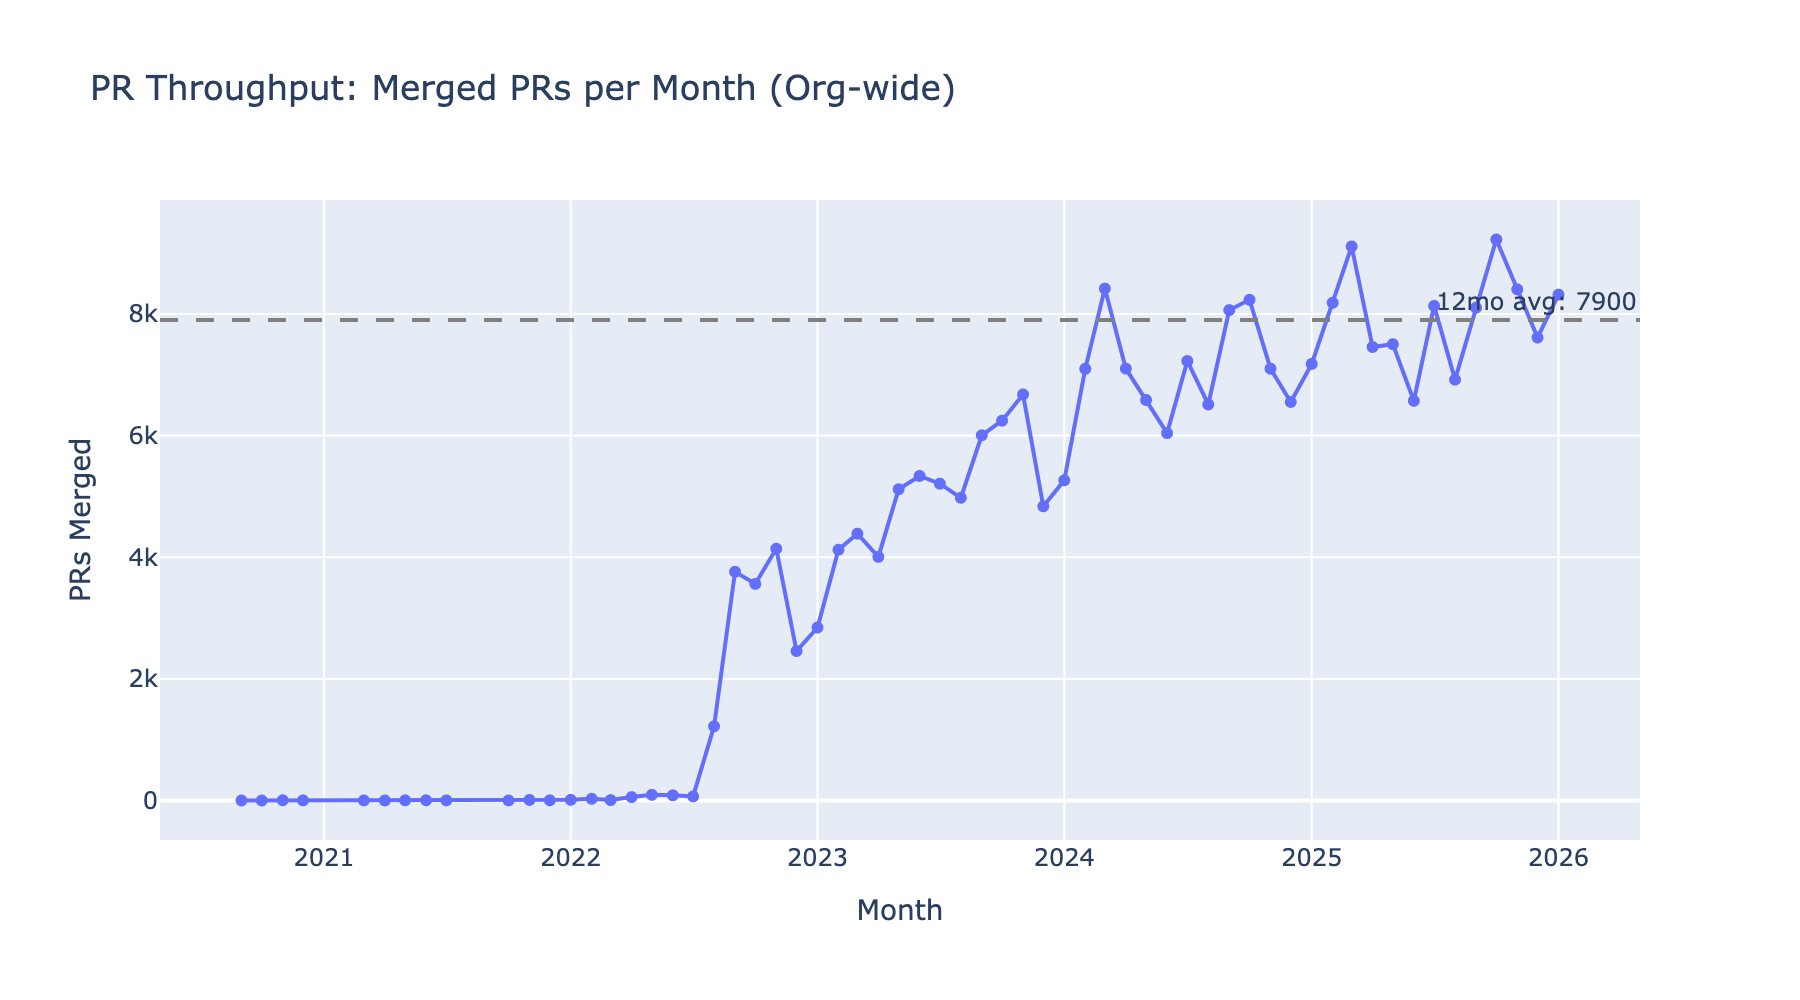


Baseline (last 12 months): 7900 PRs merged per month


In [5]:
# Visualize raw throughput
fig = px.line(df_monthly, x='month', y='prs_merged',
              title='PR Throughput: Merged PRs per Month (Org-wide)',
              markers=True)
fig.update_layout(yaxis_title='PRs Merged', xaxis_title='Month')

# Add 12-month average line (more meaningful than all-time given sparse early data)
recent_12mo = df_monthly[df_monthly['month_dt'] >= df_monthly['month_dt'].max() - pd.DateOffset(months=12)]
avg_prs_12mo = recent_12mo['prs_merged'].mean()
fig.add_hline(y=avg_prs_12mo, line_dash="dash", line_color="gray", 
              annotation_text=f"12mo avg: {avg_prs_12mo:.0f}")

fig.show()

print(f"\nBaseline (last 12 months): {avg_prs_12mo:.0f} PRs merged per month")

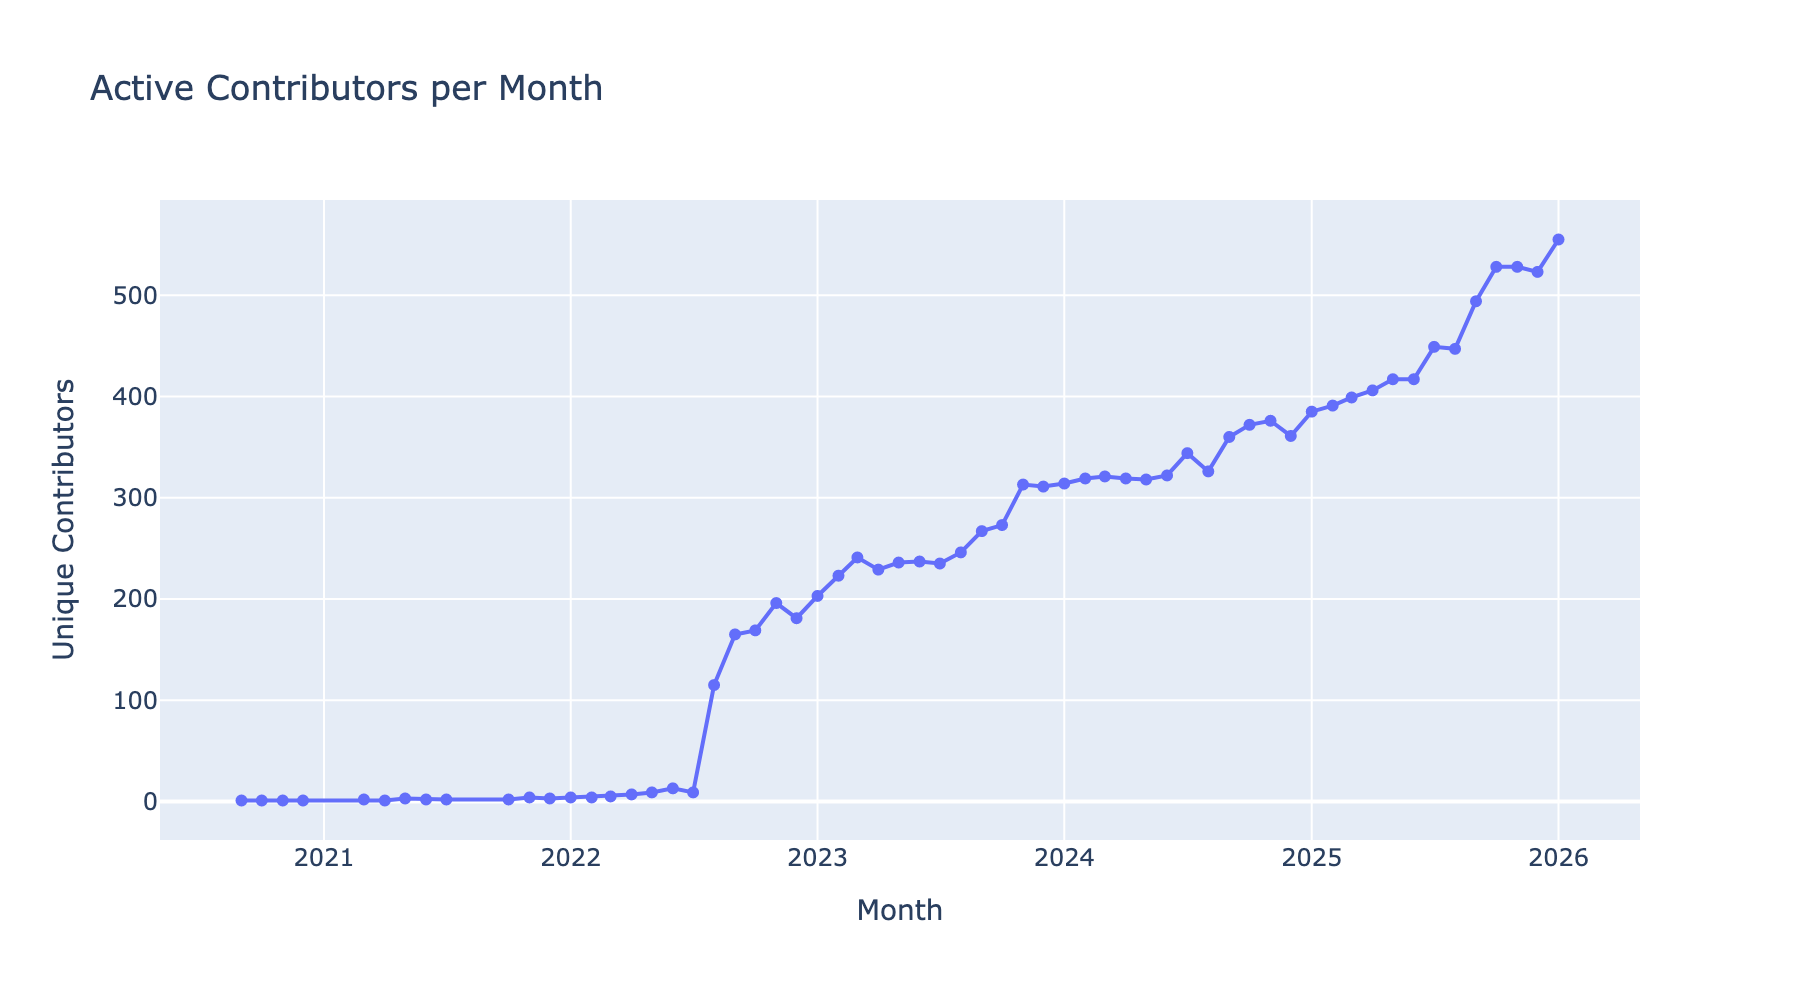

In [6]:
# Visualize contributors over time
fig = px.line(df_monthly, x='month', y='contributors',
              title='Active Contributors per Month',
              markers=True)
fig.update_layout(yaxis_title='Unique Contributors', xaxis_title='Month')
fig.show()

## 3. Throughput per Contributor (Normalized)

This tells us if productivity per person is improving, or if throughput growth is just from hiring.

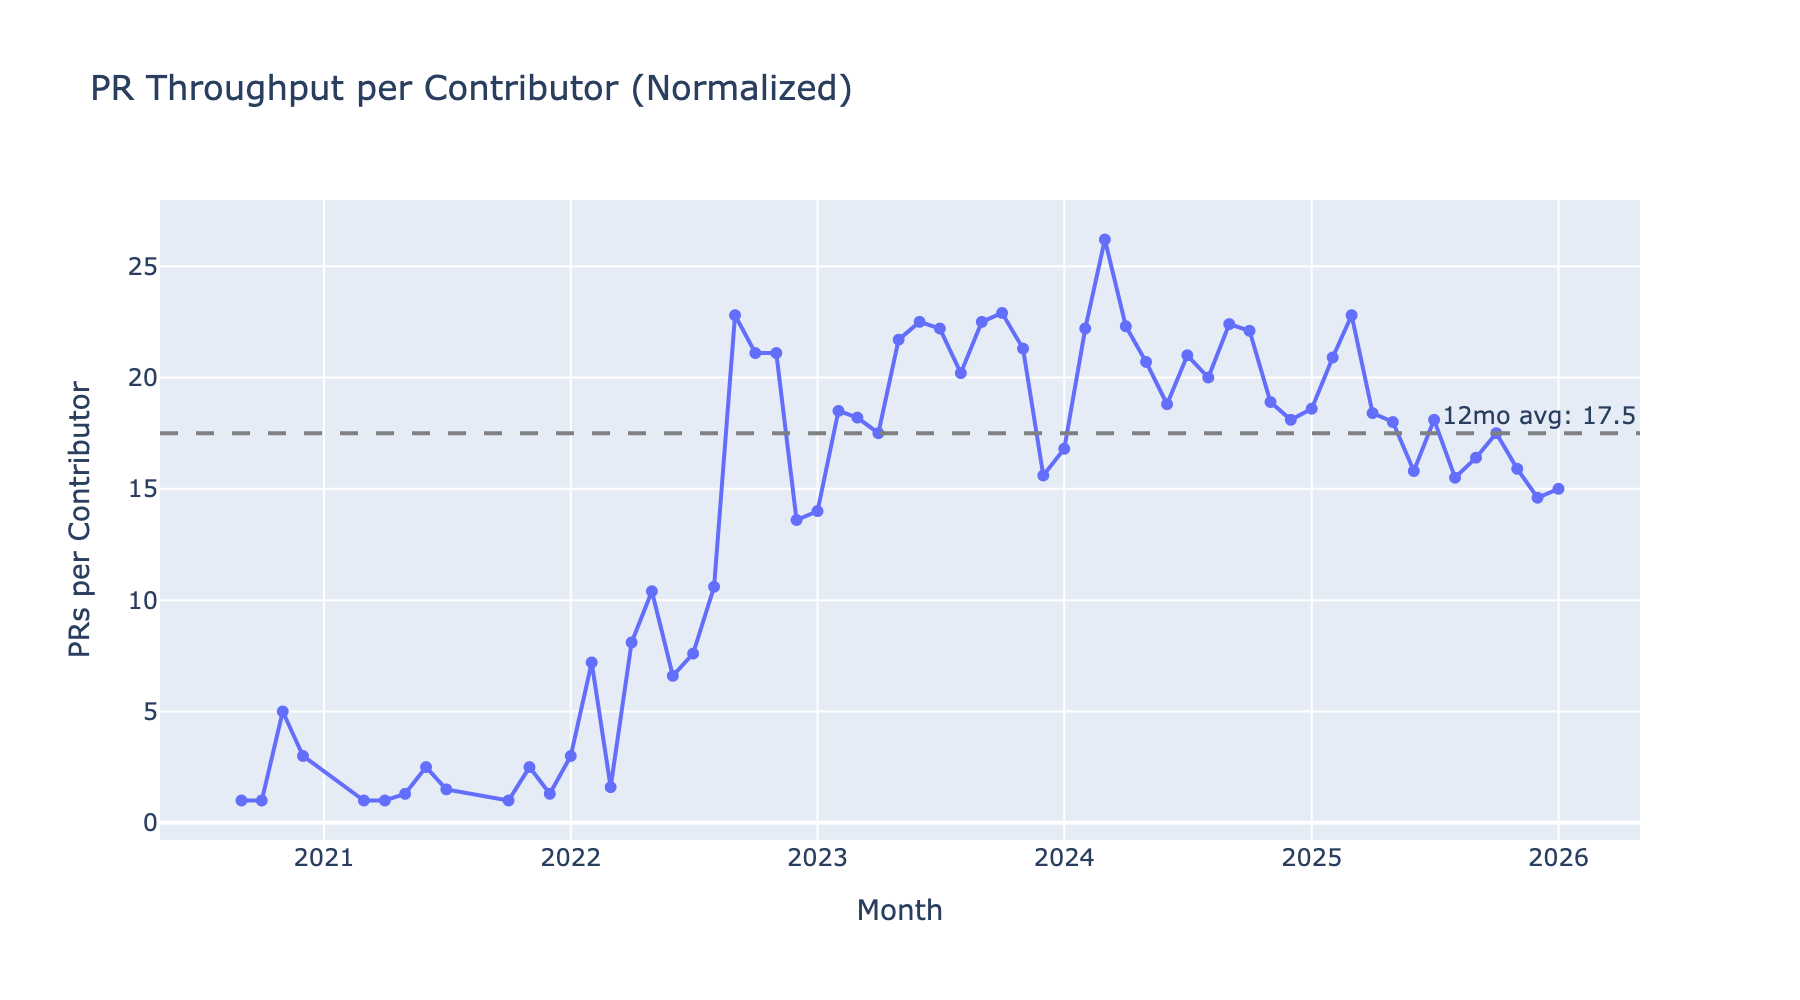


Baseline (last 12 months): 17.5 PRs per contributor per month


In [7]:
# Visualize per-capita throughput
fig = px.line(df_monthly, x='month', y='prs_per_contributor',
              title='PR Throughput per Contributor (Normalized)',
              markers=True)
fig.update_layout(yaxis_title='PRs per Contributor', xaxis_title='Month')

# Add 12-month average line
recent_12mo = df_monthly[df_monthly['month_dt'] >= df_monthly['month_dt'].max() - pd.DateOffset(months=12)]
avg_per_capita_12mo = recent_12mo['prs_per_contributor'].mean()
fig.add_hline(y=avg_per_capita_12mo, line_dash="dash", line_color="gray",
              annotation_text=f"12mo avg: {avg_per_capita_12mo:.1f}")

fig.show()

print(f"\nBaseline (last 12 months): {avg_per_capita_12mo:.1f} PRs per contributor per month")

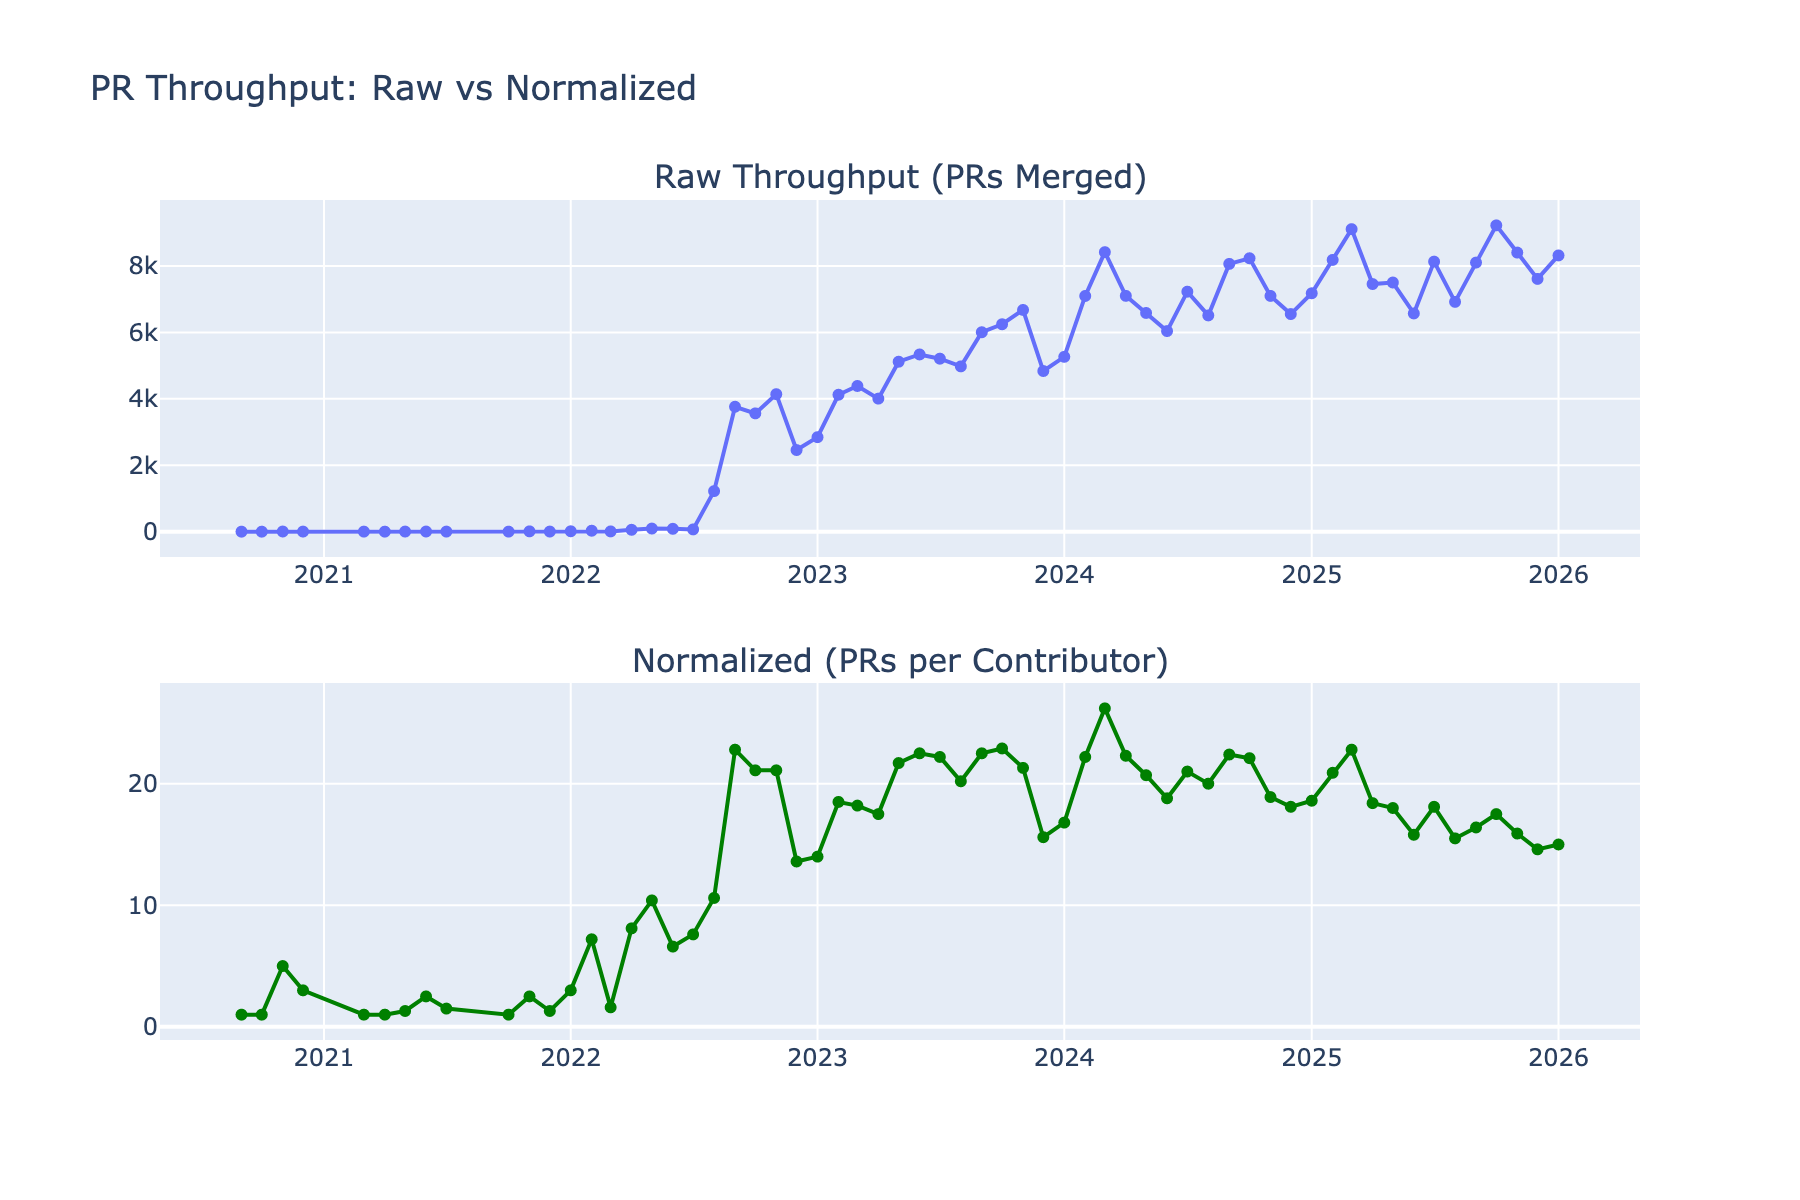

In [8]:
# Combined view: Raw vs Normalized
fig = make_subplots(rows=2, cols=1, 
                    subplot_titles=('Raw Throughput (PRs Merged)', 'Normalized (PRs per Contributor)'),
                    vertical_spacing=0.15)

fig.add_trace(
    go.Scatter(x=df_monthly['month'], y=df_monthly['prs_merged'], 
               mode='lines+markers', name='PRs Merged'),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=df_monthly['month'], y=df_monthly['prs_per_contributor'], 
               mode='lines+markers', name='PRs per Contributor', line=dict(color='green')),
    row=2, col=1
)

fig.update_layout(height=600, title_text='PR Throughput: Raw vs Normalized', showlegend=False)
fig.show()

# Export manually: fig.write_image('pr-throughput-raw-vs-normalized.png')

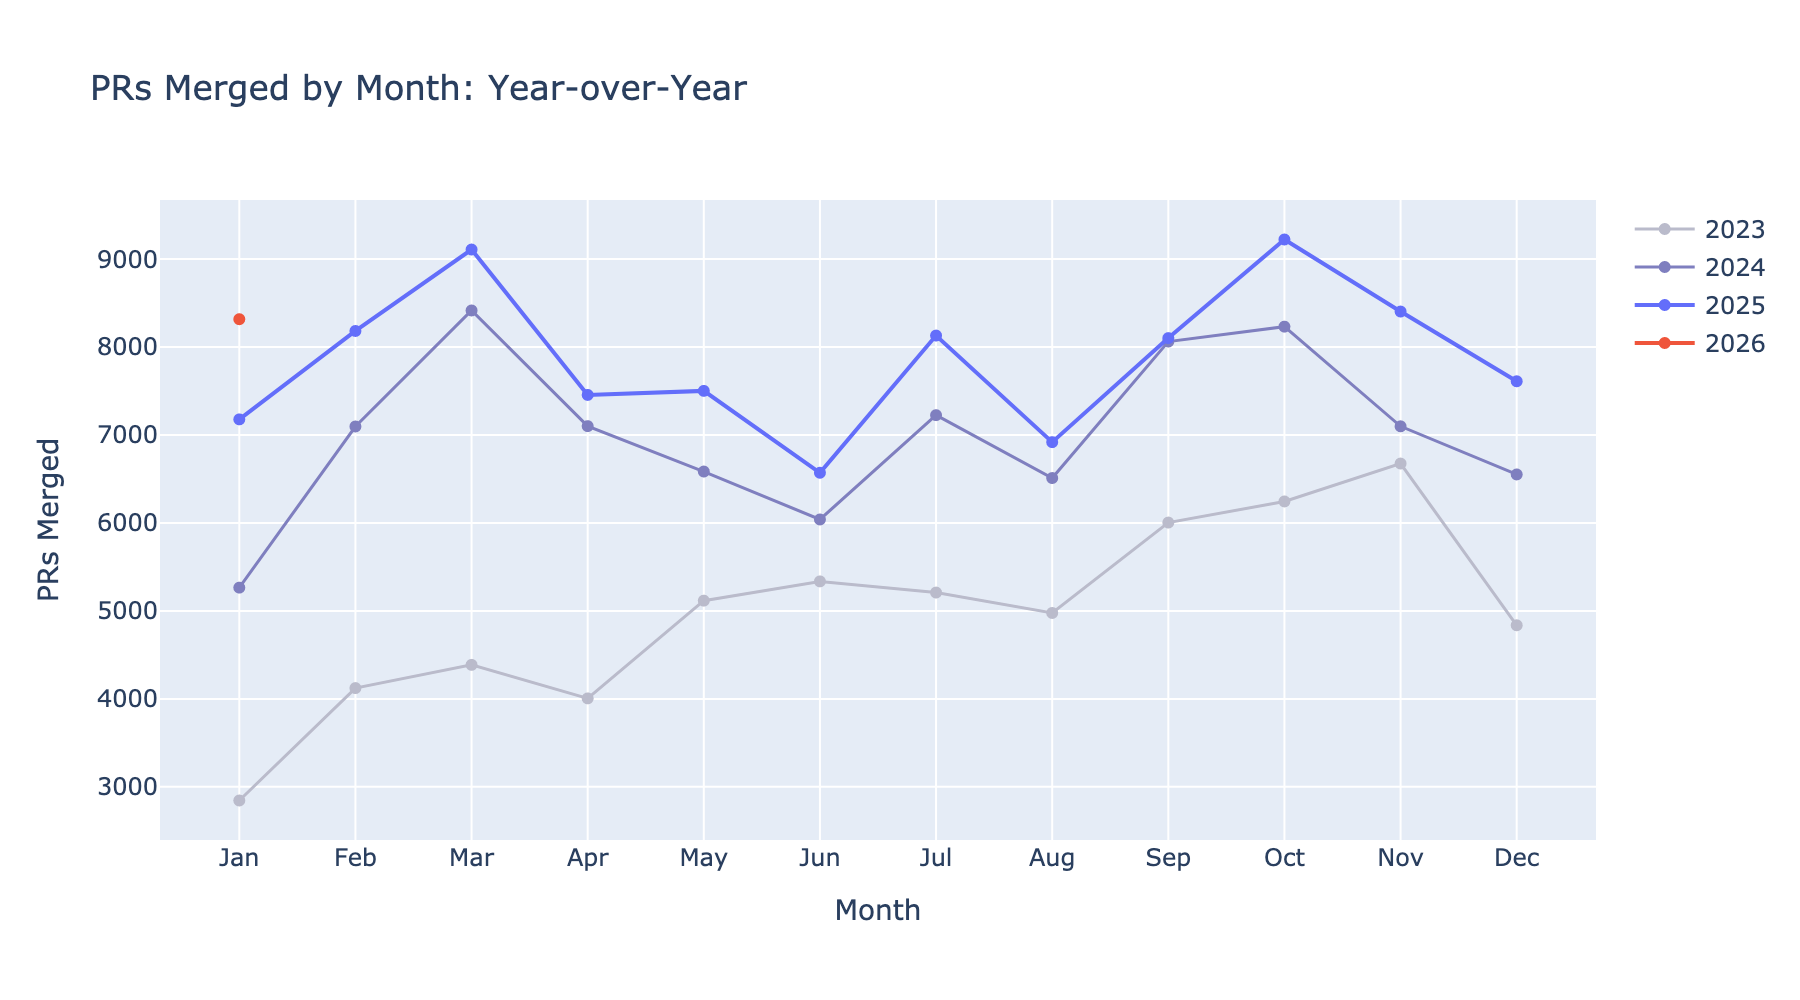

2024 vs 2023 (comparable months): +41%
2025 vs 2024 (comparable months): +12%


In [9]:
# YoY comparison: overlaid lines, one per year
df_monthly['year'] = df_monthly['month_dt'].dt.year
df_monthly['month_num'] = df_monthly['month_dt'].dt.month

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
colors = {'2023': '#BABBCB', '2024': '#7F7FBF', '2025': '#636EFA', '2026': '#EF553B'}

fig = go.Figure()
for year in [2023, 2024, 2025, 2026]:
    yr_data = df_monthly[df_monthly['year'] == year].sort_values('month_num')
    if len(yr_data) == 0:
        continue
    fig.add_trace(go.Scatter(
        x=[month_labels[m-1] for m in yr_data['month_num']],
        y=yr_data['prs_merged'],
        mode='lines+markers',
        name=str(year),
        line=dict(color=colors.get(str(year), '#636EFA'), width=2 if year >= 2025 else 1.5),
    ))

fig.update_layout(
    title='PRs Merged by Month: Year-over-Year',
    yaxis_title='PRs Merged',
    xaxis_title='Month',
)
fig.show()

# YoY growth rates
df_yoy = df_monthly[df_monthly['year'] >= 2023].pivot(index='month_num', columns='year', values='prs_merged')
for year in [2024, 2025]:
    if year in df_yoy.columns and (year - 1) in df_yoy.columns:
        prev = df_yoy[year - 1].dropna()
        curr = df_yoy[year].dropna()
        common = prev.index.intersection(curr.index)
        if len(common) > 0:
            growth = (curr[common].sum() - prev[common].sum()) / prev[common].sum() * 100
            print(f"{year} vs {year-1} (comparable months): {growth:+.0f}%")

## 4. Breakdown by Area

Filtered to top-level Swarmia teams (excluding AI Pilot, Productivity, Quant, Test Team).

**Caveat**: Uses Swarmia's `owner_team_names` which reflects the team that owned the PR at the time. This is historically accurate but team structure has evolved.

In [10]:
# Areas to include in breakdown (top-level Swarmia teams, excluding internal/test)
AREAS = ['Core Experience', 'Data', 'Gaming', 'Platform', 'Player', 'Social', 'Sports']

print(f"Analyzing {len(AREAS)} areas: {', '.join(AREAS)}")

Analyzing 7 areas: Core Experience, Data, Gaming, Platform, Player, Social, Sports


In [11]:
# Monthly throughput by area (excluding current incomplete month)
areas_str = "', '".join(AREAS)

df_by_area = run_query(f"""
WITH pr_flattened AS (
  SELECT
    DATE_TRUNC('month', pr.github_created_at)::DATE as month,
    pr.author_id,
    f.value::string as area
  FROM RAW_MISC.SWARMIA_PULL_REQUESTS pr,
  LATERAL FLATTEN(input => pr.owner_team_names) f
  WHERE pr.pr_status = 'MERGED'
    AND pr.is_excluded = FALSE
    AND pr.github_created_at IS NOT NULL
    AND f.value::string IN ('{areas_str}')
    AND DATE_TRUNC('month', pr.github_created_at) < DATE_TRUNC('month', CURRENT_DATE)  -- exclude current month
)
SELECT
  month,
  area,
  COUNT(*) as prs_merged,
  COUNT(DISTINCT author_id) as contributors
FROM pr_flattened
GROUP BY 1, 2
ORDER BY 1, 2
""")

df_by_area['prs_per_contributor'] = (df_by_area['prs_merged'] / df_by_area['contributors']).round(1)

print(f"Data through: {df_by_area['month'].max()}")
print(f"Data shape: {df_by_area.shape}")
df_by_area.tail(10)

Data through: 2026-01-01
Data shape: (303, 5)


,month,area,prs_merged,contributors,prs_per_contributor
293,2025-12-01,Player,1096,135,8.1
294,2025-12-01,Social,281,25,11.2
295,2025-12-01,Sports,1251,116,10.8
296,2026-01-01,Core Experience,255,22,11.6
297,2026-01-01,Data,1062,63,16.9
298,2026-01-01,Gaming,515,37,13.9
299,2026-01-01,Platform,925,49,18.9
300,2026-01-01,Player,1286,141,9.1
301,2026-01-01,Social,329,27,12.2
302,2026-01-01,Sports,1284,116,11.1


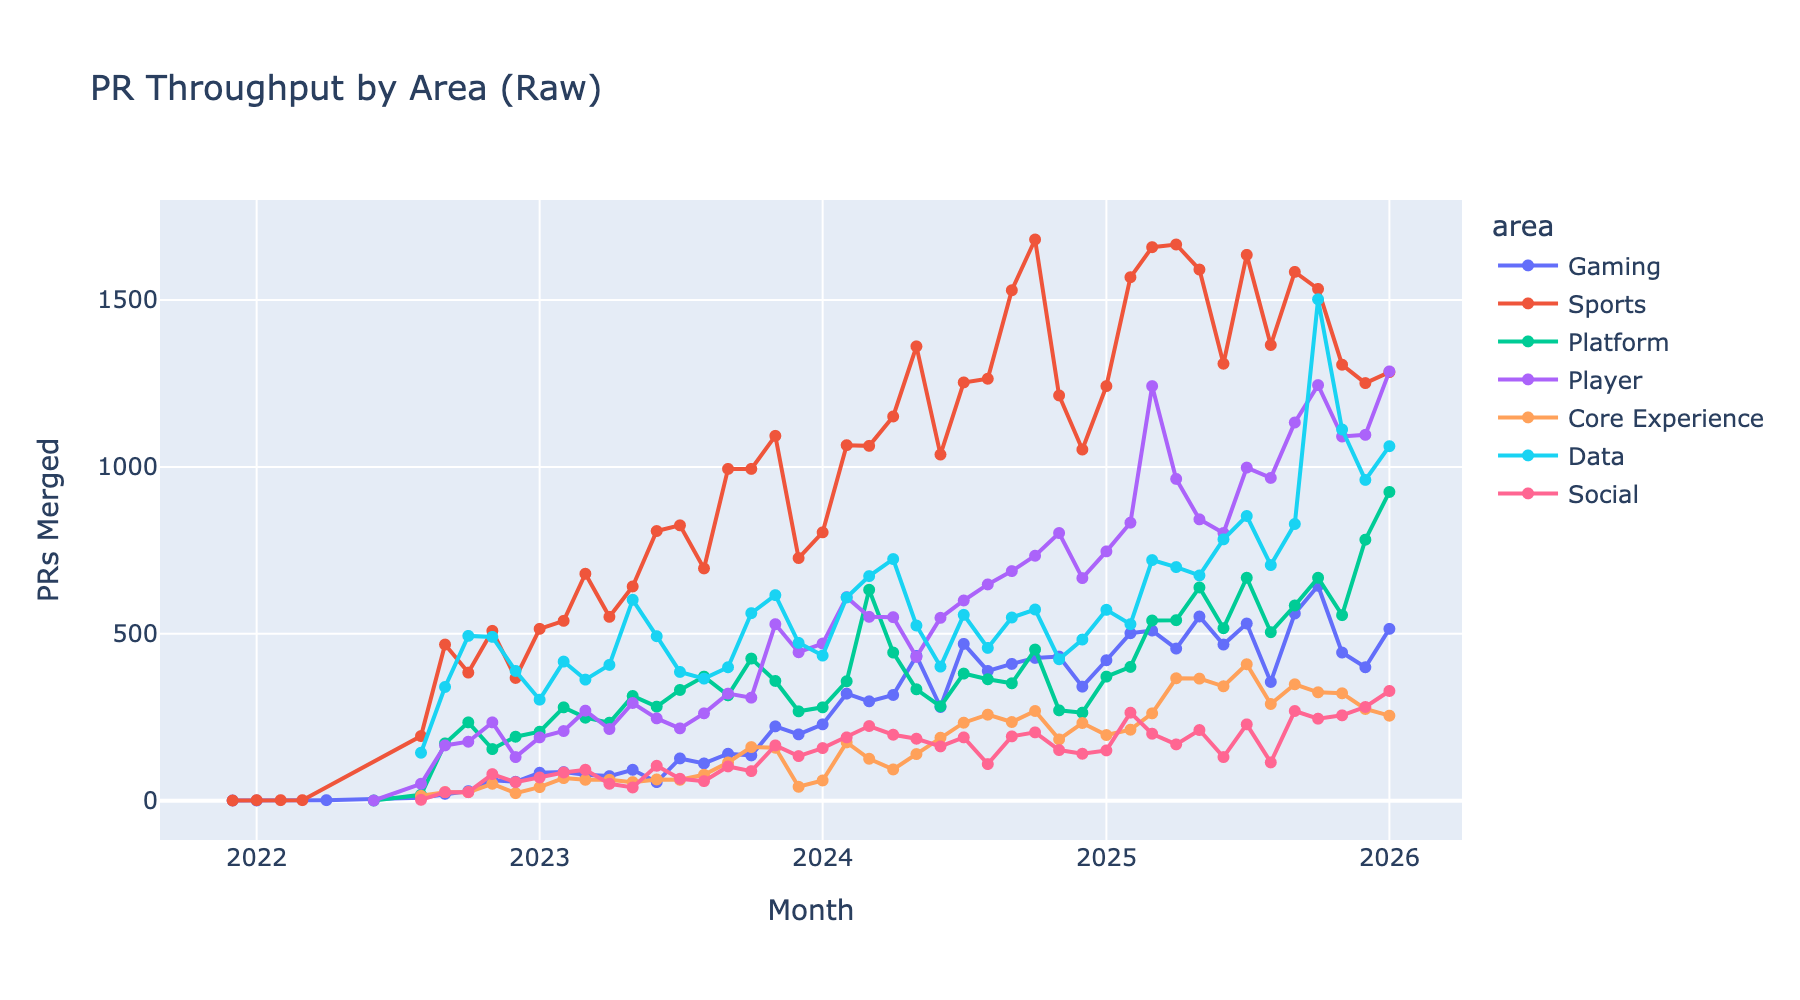

In [12]:
# Raw throughput over time by area
fig = px.line(df_by_area, x='month', y='prs_merged', color='area',
              title='PR Throughput by Area (Raw)',
              markers=True)
fig.update_layout(yaxis_title='PRs Merged', xaxis_title='Month')
fig.show()

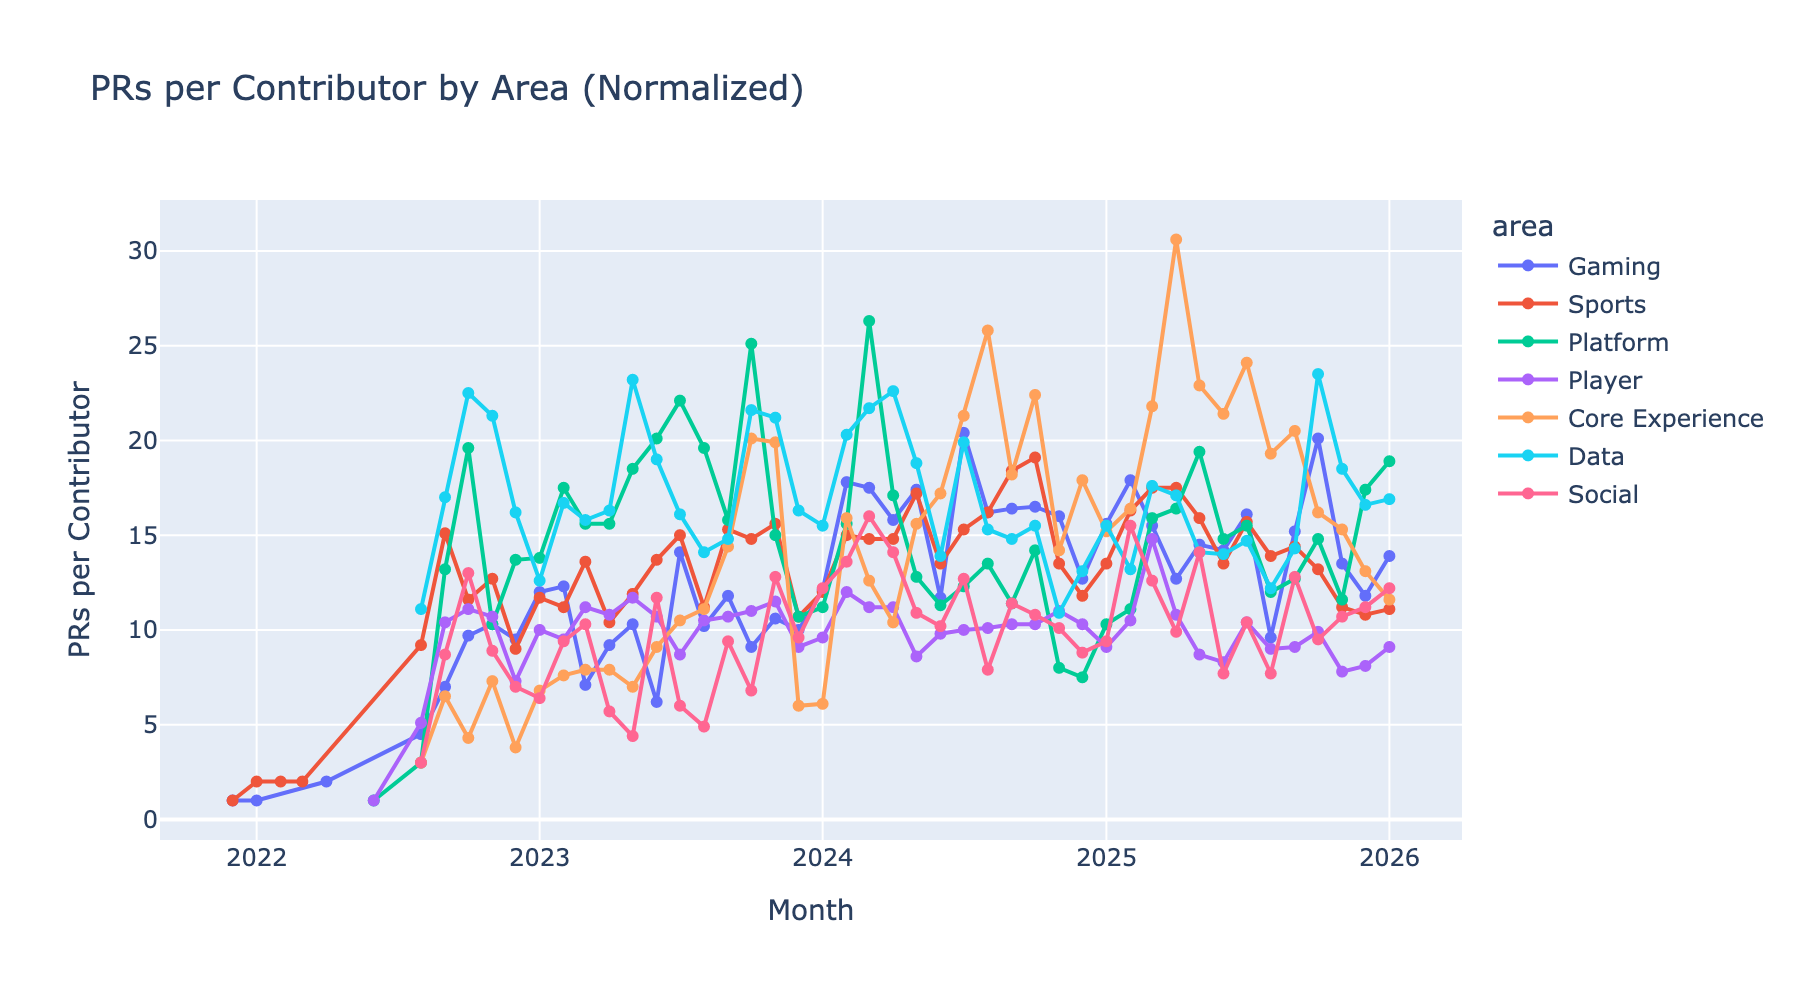

In [13]:
# Normalized throughput (PRs per contributor) by area
fig = px.line(df_by_area, x='month', y='prs_per_contributor', color='area',
              title='PRs per Contributor by Area (Normalized)',
              markers=True)
fig.update_layout(yaxis_title='PRs per Contributor', xaxis_title='Month')
fig.show()

# Export manually: fig.write_image('pr-throughput-by-area-normalized.png')

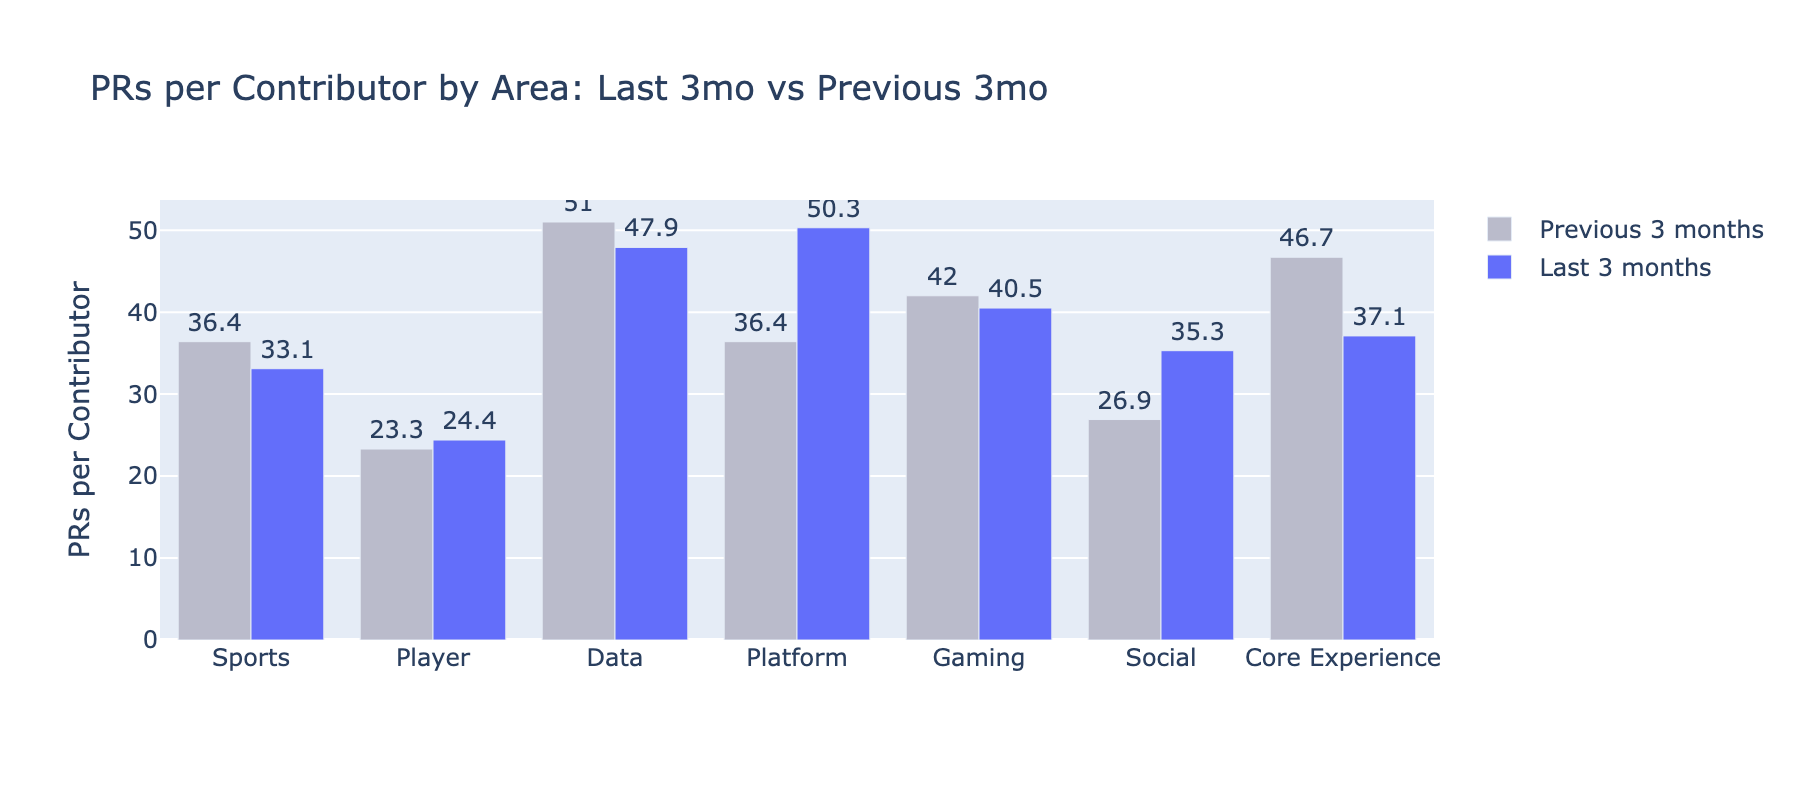

  Sports                -6.0% raw PR growth
  Player                +9.9% raw PR growth
  Data                  -3.4% raw PR growth
  Platform              +41.1% raw PR growth
  Gaming                -3.4% raw PR growth
  Social                +31.2% raw PR growth
  Core Experience       -5.4% raw PR growth


In [14]:
# Area performance: last 3 months vs previous 3 months
areas_str = "', '".join(AREAS)

df_area_summary = run_query(f"""
WITH pr_flattened AS (
  SELECT
    pr.github_created_at,
    pr.author_id,
    f.value::string as area
  FROM RAW_MISC.SWARMIA_PULL_REQUESTS pr,
  LATERAL FLATTEN(input => pr.owner_team_names) f
  WHERE pr.pr_status = 'MERGED'
    AND pr.is_excluded = FALSE
    AND pr.github_created_at IS NOT NULL
    AND f.value::string IN ('{areas_str}')
),
recent AS (
  SELECT 
    area,
    COUNT(*) as prs_recent,
    COUNT(DISTINCT author_id) as contributors_recent
  FROM pr_flattened
  WHERE github_created_at >= DATEADD('month', -3, CURRENT_DATE)
  GROUP BY 1
),
previous AS (
  SELECT 
    area,
    COUNT(*) as prs_previous,
    COUNT(DISTINCT author_id) as contributors_previous
  FROM pr_flattened
  WHERE github_created_at >= DATEADD('month', -6, CURRENT_DATE)
    AND github_created_at < DATEADD('month', -3, CURRENT_DATE)
  GROUP BY 1
)
SELECT 
  COALESCE(r.area, p.area) as area,
  COALESCE(r.prs_recent, 0) as prs_last_3mo,
  COALESCE(r.contributors_recent, 0) as contributors_last_3mo,
  ROUND(COALESCE(r.prs_recent, 0) * 1.0 / NULLIF(COALESCE(r.contributors_recent, 0), 0), 1) as prs_per_contributor_last_3mo,
  COALESCE(p.prs_previous, 0) as prs_prev_3mo,
  COALESCE(p.contributors_previous, 0) as contributors_prev_3mo,
  ROUND(COALESCE(p.prs_previous, 0) * 1.0 / NULLIF(COALESCE(p.contributors_previous, 0), 0), 1) as prs_per_contributor_prev_3mo,
  CASE WHEN COALESCE(p.prs_previous, 0) > 0 
       THEN ROUND(100.0 * (COALESCE(r.prs_recent, 0) - p.prs_previous) / p.prs_previous, 1)
       ELSE NULL END as prs_growth_pct
FROM recent r
FULL OUTER JOIN previous p ON r.area = p.area
ORDER BY prs_last_3mo DESC
""")

# Grouped bar chart: last 3mo vs prev 3mo by area
fig = go.Figure()

fig.add_trace(go.Bar(
    name='Previous 3 months',
    x=df_area_summary['area'], y=df_area_summary['prs_per_contributor_prev_3mo'],
    text=df_area_summary['prs_per_contributor_prev_3mo'],
    textposition='outside',
    marker_color='#BABBCB'
))

fig.add_trace(go.Bar(
    name='Last 3 months',
    x=df_area_summary['area'], y=df_area_summary['prs_per_contributor_last_3mo'],
    text=df_area_summary['prs_per_contributor_last_3mo'],
    textposition='outside',
    marker_color='#636EFA'
))

fig.update_layout(
    title='PRs per Contributor by Area: Last 3mo vs Previous 3mo',
    yaxis_title='PRs per Contributor',
    barmode='group',
    height=400
)
fig.show()

# Growth annotation
for _, row in df_area_summary.iterrows():
    direction = '+' if row['prs_growth_pct'] and row['prs_growth_pct'] > 0 else ''
    print(f"  {row['area']:20s}  {direction}{row['prs_growth_pct']}% raw PR growth")

In [15]:
# Area comparison: 6-month average PRs per contributor
# This smooths out month-to-month variance for more reliable comparison

df_by_area['month_dt'] = pd.to_datetime(df_by_area['month'])
six_months_ago = df_by_area['month_dt'].max() - pd.DateOffset(months=6)

df_area_6mo = df_by_area[df_by_area['month_dt'] > six_months_ago].groupby('area').agg({
    'prs_per_contributor': ['mean', 'std', 'min', 'max'],
    'prs_merged': 'sum',
    'contributors': 'mean'
}).round(1)

df_area_6mo.columns = ['avg_prs_per_contributor', 'std', 'min', 'max', 'total_prs', 'avg_contributors']
df_area_6mo = df_area_6mo.sort_values('avg_prs_per_contributor', ascending=False)

print("6-Month Average: PRs per Contributor by Area")
print("=" * 60)
df_area_6mo

6-Month Average: PRs per Contributor by Area


,avg_prs_per_contributor,std,min,max,total_prs,avg_contributors
area,,,,,,
Data,17.0,3.9,12.2,23.5,6172,60.2
Core Experience,16.0,3.4,11.6,20.5,1816,19.3
Platform,14.6,3.0,11.6,18.9,4021,45.8
Gaming,14.0,3.6,9.6,20.1,2920,35.0
Sports,12.4,1.6,10.8,14.4,8323,112.2
Social,10.7,1.9,7.7,12.8,1496,23.0
Player,8.8,0.8,7.8,9.9,6818,129.0


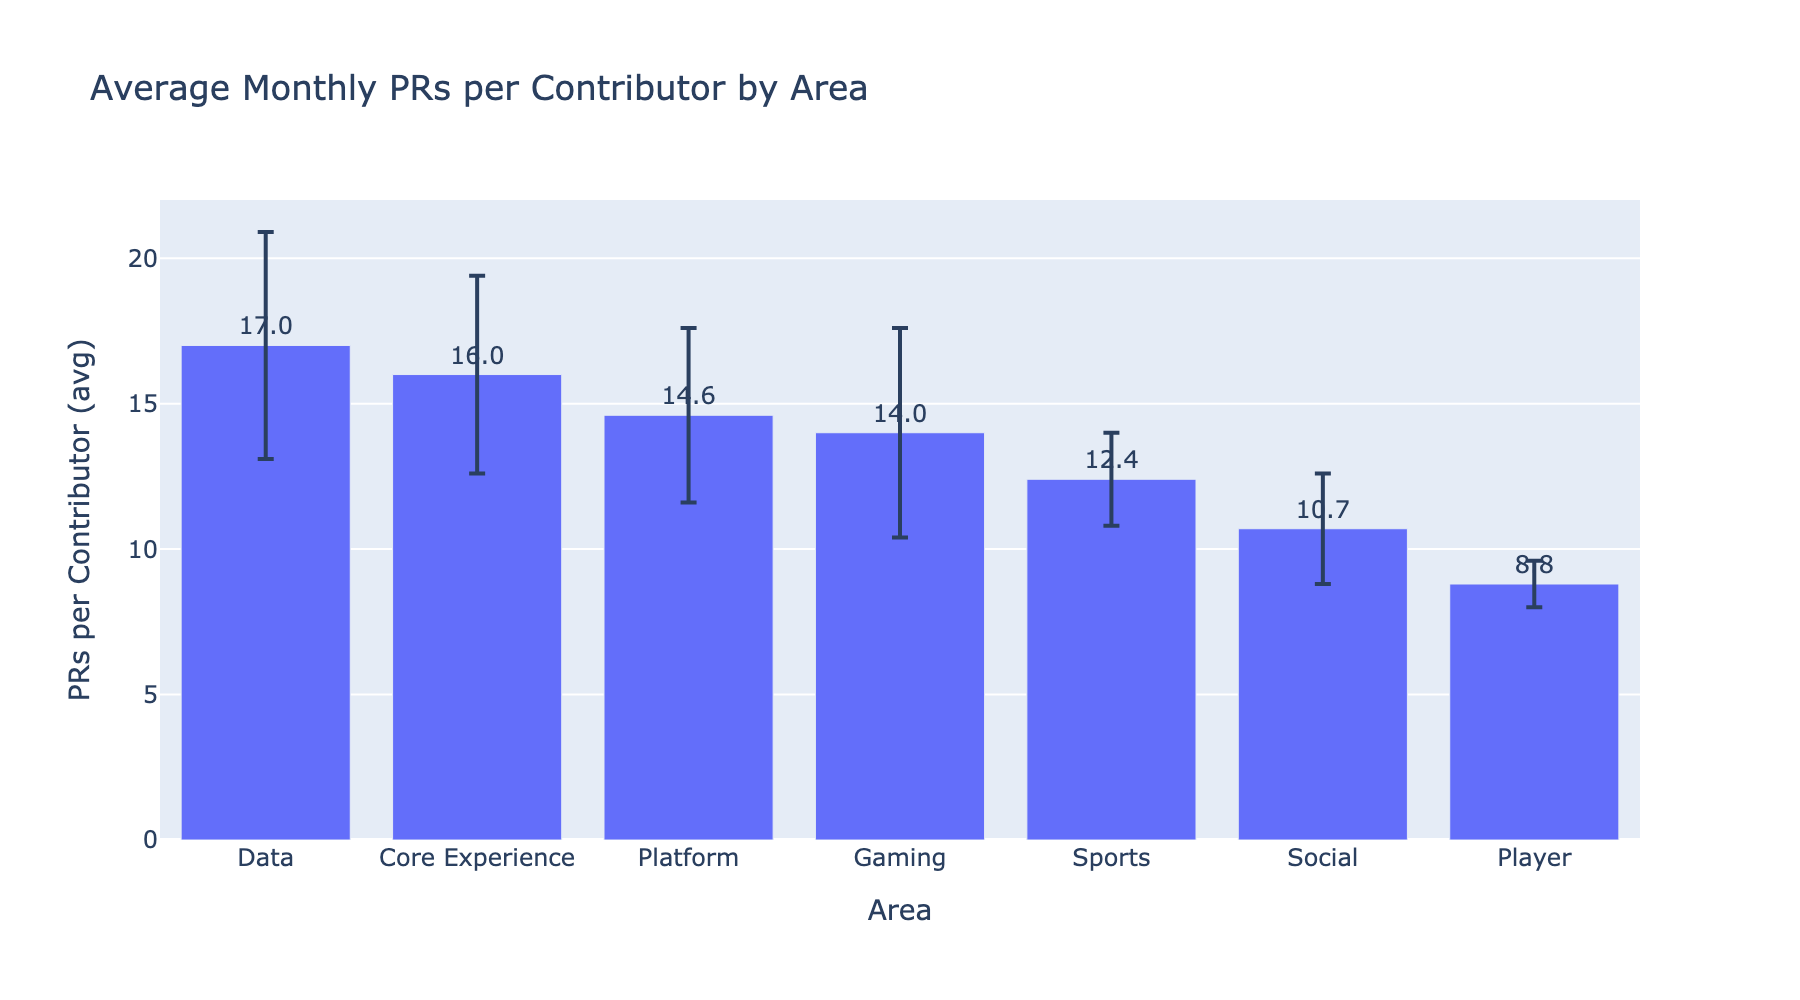


Key finding:
  - Highest: Data (17.0 PRs/contributor)
  - Lowest: Player (8.8 PRs/contributor)
  - Ratio: 1.9x difference


In [16]:
# Bar chart: 6-month average PRs per contributor by area
fig = px.bar(df_area_6mo.reset_index(), 
             x='area', 
             y='avg_prs_per_contributor',
             error_y='std',
             title='Average Monthly PRs per Contributor by Area',
             text='avg_prs_per_contributor')
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')
fig.update_layout(yaxis_title='PRs per Contributor (avg)', xaxis_title='Area')
fig.show()

# Export manually: fig.write_image('pr-throughput-by-area-comparison.png')

# Print key insight
highest = df_area_6mo['avg_prs_per_contributor'].idxmax()
lowest = df_area_6mo['avg_prs_per_contributor'].idxmin()
highest_val = df_area_6mo.loc[highest, 'avg_prs_per_contributor']
lowest_val = df_area_6mo.loc[lowest, 'avg_prs_per_contributor']

print(f"\nKey finding:")
print(f"  - Highest: {highest} ({highest_val:.1f} PRs/contributor)")
print(f"  - Lowest: {lowest} ({lowest_val:.1f} PRs/contributor)")
print(f"  - Ratio: {highest_val/lowest_val:.1f}x difference")

## 5. Work Granularity: Commits per PR

How many commits go into each PR? A shift in this ratio signals changing development patterns — more iterative workflows, different tooling, or AI-assisted development.

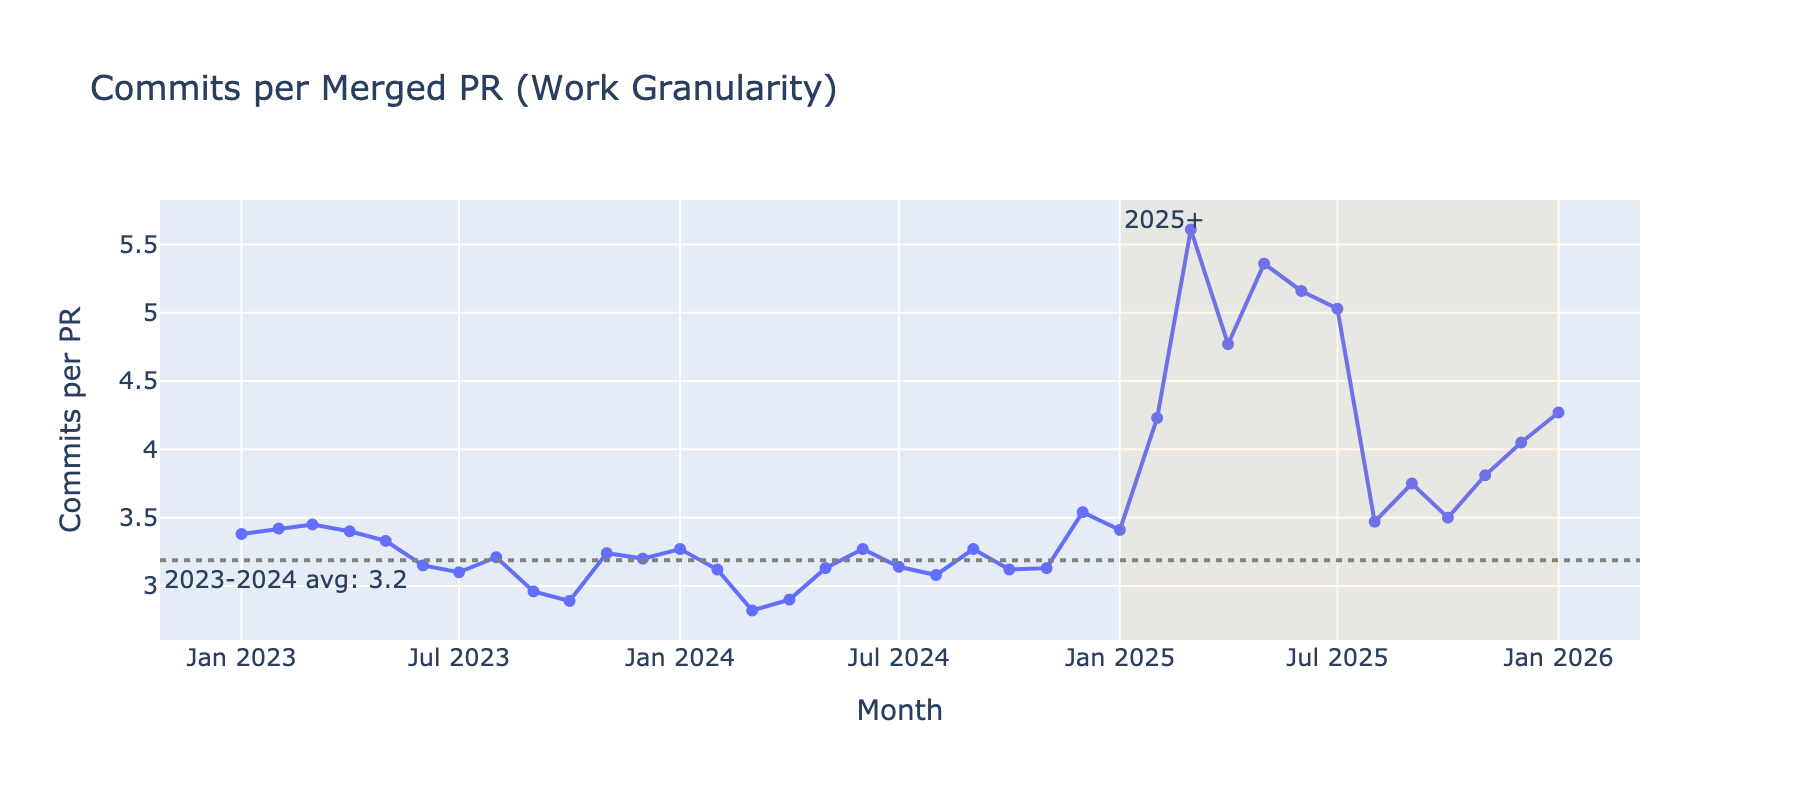

2023-2024 baseline: 3.2 commits/PR
2025+:              4.3 commits/PR (+36%)

More commits per PR suggests more iterative development — possibly AI-assisted workflows generating smaller, incremental commits.


In [17]:
# Commits per merged PR over time (work granularity)
df_commits_per_pr = run_query("""
WITH monthly_commits AS (
  SELECT 
    DATE_TRUNC('month', c.committed_date)::DATE as month,
    COUNT(*) as commits
  FROM RAW_MISC.SWARMIA_COMMITS c
  WHERE c.associated_pull_request_ids IS NOT NULL 
    AND ARRAY_SIZE(c.associated_pull_request_ids) > 0
    AND committed_date >= '2023-01-01'
    AND DATE_TRUNC('month', committed_date) < DATE_TRUNC('month', CURRENT_DATE)
  GROUP BY 1
),
monthly_prs AS (
  SELECT
    DATE_TRUNC('month', github_created_at)::DATE as month,
    COUNT(*) as prs
  FROM RAW_MISC.SWARMIA_PULL_REQUESTS
  WHERE pr_status = 'MERGED' AND is_excluded = FALSE
    AND github_created_at >= '2023-01-01'
    AND DATE_TRUNC('month', github_created_at) < DATE_TRUNC('month', CURRENT_DATE)
  GROUP BY 1
)
SELECT 
  c.month,
  c.commits as pr_commits,
  p.prs as prs_merged,
  ROUND(c.commits * 1.0 / p.prs, 2) as commits_per_pr
FROM monthly_commits c
JOIN monthly_prs p ON c.month = p.month
ORDER BY 1
""")

df_commits_per_pr['month_dt'] = pd.to_datetime(df_commits_per_pr['month'])

pre_2025 = df_commits_per_pr[df_commits_per_pr['month_dt'] < '2025-01-01']
post_2025 = df_commits_per_pr[df_commits_per_pr['month_dt'] >= '2025-01-01']

pre_avg = pre_2025['commits_per_pr'].mean()
post_avg = post_2025['commits_per_pr'].mean()

# Chart
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_commits_per_pr['month'], y=df_commits_per_pr['commits_per_pr'],
    mode='lines+markers', name='Commits per PR',
    line=dict(color='#636EFA')
))

fig.add_hline(y=pre_avg, line_dash="dot", line_color="gray",
              annotation_text=f"2023-2024 avg: {pre_avg:.1f}", annotation_position="bottom left")

x0_date = pd.Timestamp('2025-01-01').date()
x1_date = df_commits_per_pr['month'].max()
fig.add_vrect(x0=x0_date, x1=x1_date,
              fillcolor='orange', opacity=0.08, line_width=0,
              annotation_text='2025+', annotation_position='top left')

fig.update_layout(
    title='Commits per Merged PR (Work Granularity)',
    yaxis_title='Commits per PR',
    xaxis_title='Month',
    height=400
)

fig.show()

print(f"2023-2024 baseline: {pre_avg:.1f} commits/PR")
print(f"2025+:              {post_avg:.1f} commits/PR (+{((post_avg / pre_avg) - 1) * 100:.0f}%)")
print(f"\nMore commits per PR suggests more iterative development — possibly AI-assisted workflows generating smaller, incremental commits.")

## 6. Insights & Summary

Key findings to include in the report.

In [18]:
# Calculate key metrics for the report
latest_month = df_monthly['month'].max()
latest_data = df_monthly[df_monthly['month'] == latest_month].iloc[0]

twelve_months_ago = pd.to_datetime(latest_month) - pd.DateOffset(months=12)
yoy_data = df_monthly[df_monthly['month_dt'] <= twelve_months_ago].tail(1)

print("=" * 60)
print("KEY METRICS FOR REPORT")
print("=" * 60)

print(f"\nLatest month ({latest_month}):")
print(f"  - PRs merged: {latest_data['prs_merged']:,}")
print(f"  - Contributors: {latest_data['contributors']:,}")
print(f"  - PRs per contributor: {latest_data['prs_per_contributor']:.1f}")

print(f"\nBaseline (12mo average):")
recent_12mo = df_monthly[df_monthly['month_dt'] >= df_monthly['month_dt'].max() - pd.DateOffset(months=12)]
print(f"  - PRs merged: {recent_12mo['prs_merged'].mean():,.0f} per month")
print(f"  - PRs per contributor: {recent_12mo['prs_per_contributor'].mean():.1f} per month")

if len(yoy_data) > 0:
    yoy_prs = latest_data['prs_merged']
    yoy_prs_prev = yoy_data['prs_merged'].iloc[0]
    yoy_growth = (yoy_prs - yoy_prs_prev) / yoy_prs_prev * 100
    yoy_per_capita = latest_data['prs_per_contributor']
    yoy_per_capita_prev = yoy_data['prs_per_contributor'].iloc[0]
    yoy_per_capita_growth = (yoy_per_capita - yoy_per_capita_prev) / yoy_per_capita_prev * 100
    print(f"\nYear-over-year growth:")
    print(f"  - PRs merged: {yoy_growth:+.1f}%")
    print(f"  - PRs per contributor: {yoy_per_capita_growth:+.1f}%")

print(f"\nWork Granularity:")
print(f"  - Commits per PR (2023-2024 baseline): {pre_avg:.1f}")
print(f"  - Commits per PR (2025+): {post_avg:.1f} (+{((post_avg / pre_avg) - 1) * 100:.0f}%)")

print("=" * 60)

KEY METRICS FOR REPORT

Latest month (2026-01-01):
  - PRs merged: 8,317
  - Contributors: 555
  - PRs per contributor: 15.0

Baseline (12mo average):
  - PRs merged: 7,900 per month
  - PRs per contributor: 17.5 per month

Year-over-year growth:
  - PRs merged: +15.9%
  - PRs per contributor: -19.4%

Work Granularity:
  - Commits per PR (2023-2024 baseline): 3.2
  - Commits per PR (2025+): 4.3 (+36%)


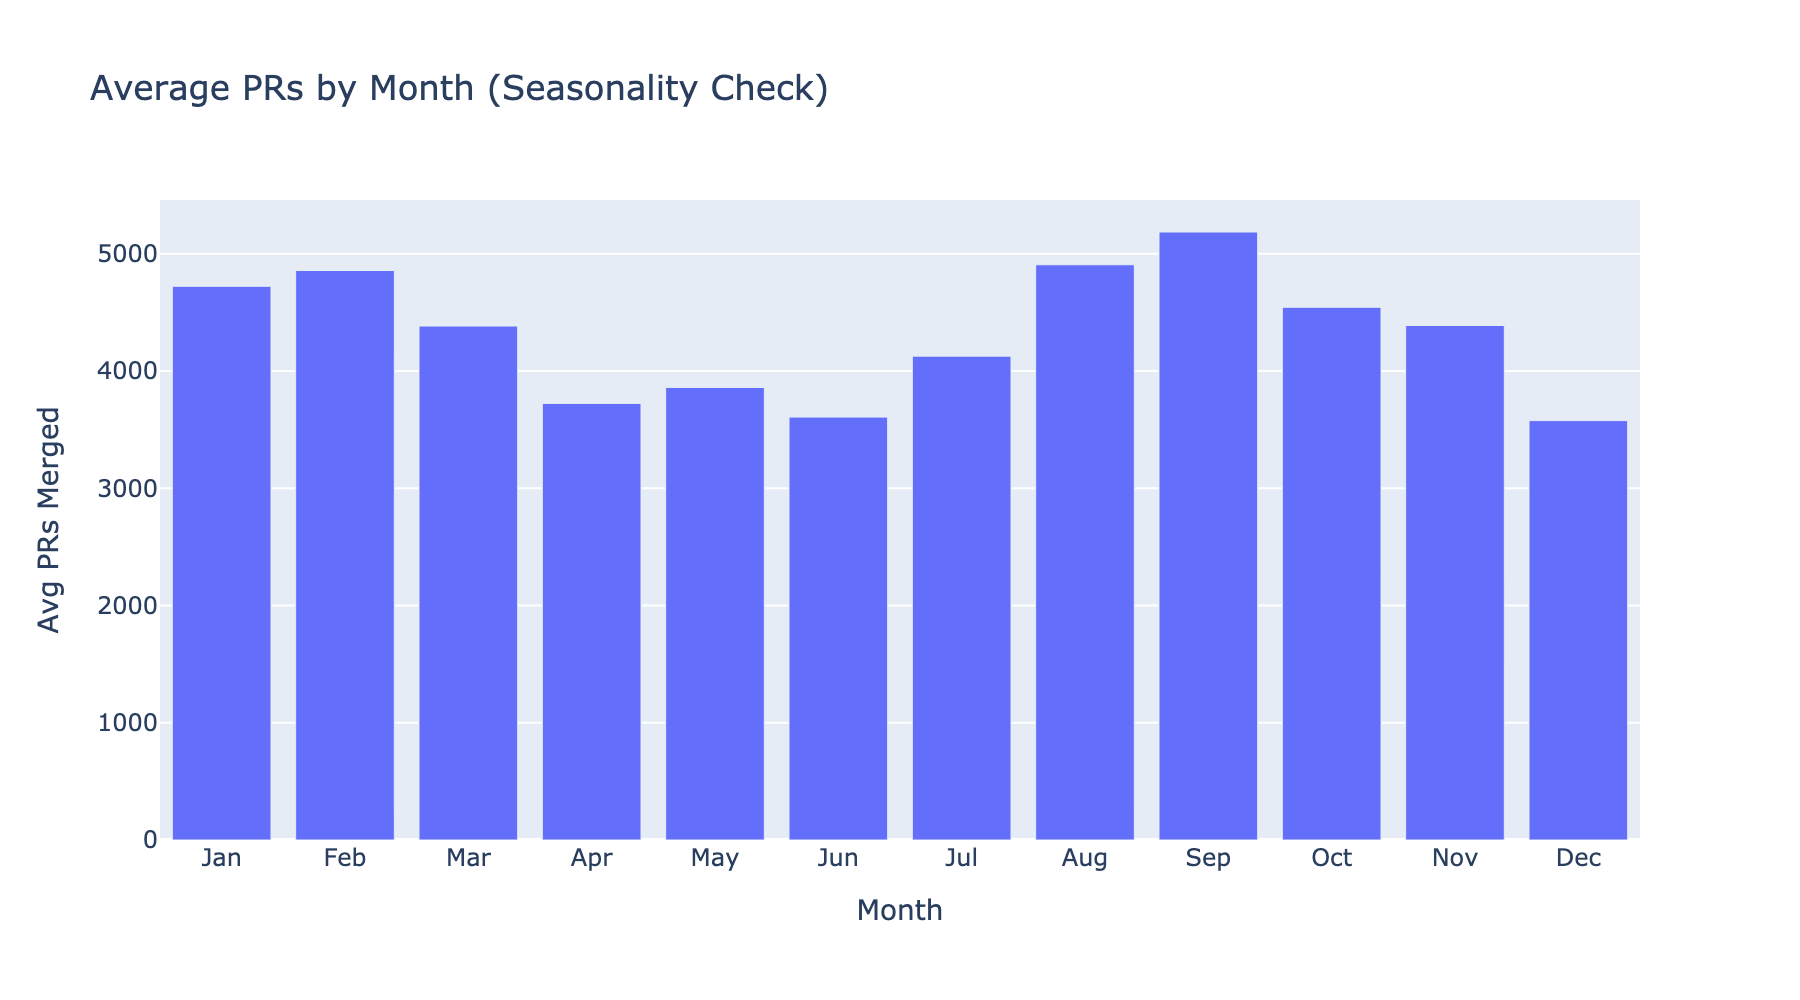


Seasonality patterns:
  - Lowest: Dec (3578 avg)
  - Highest: Sep (5186 avg)


In [19]:
# Seasonality check - are there consistent dips?
df_monthly['month_name'] = df_monthly['month_dt'].dt.strftime('%b')
df_seasonality = df_monthly.groupby('month_num').agg({
    'prs_merged': 'mean',
    'month_name': 'first'
}).sort_index()

fig = px.bar(df_seasonality.reset_index(), x='month_name', y='prs_merged',
             title='Average PRs by Month (Seasonality Check)')
fig.update_layout(xaxis_title='Month', yaxis_title='Avg PRs Merged')
fig.show()

print("\nSeasonality patterns:")
print(f"  - Lowest: {df_seasonality['month_name'].iloc[df_seasonality['prs_merged'].argmin()]} ({df_seasonality['prs_merged'].min():.0f} avg)")
print(f"  - Highest: {df_seasonality['month_name'].iloc[df_seasonality['prs_merged'].argmax()]} ({df_seasonality['prs_merged'].max():.0f} avg)")

## Next Steps

Once we're happy with this analysis, we'll:
1. Update the report markdown with actual numbers and insights
2. Save dashboard-ready queries